In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Pure summarize function

In [3]:
def summarize(seq):

    return set(seq)

def query(summary, q):

    return q in summary

test_seq = [1, 3, 5, 7, 9, 1, 3]
summary = summarize(test_seq)
print(f"Sequence: {test_seq}")
print(f"Summary: {summary}")
print(f"Query (3): {query(summary, 3)}")
print(f"Query (2): {query(summary, 2)}")

Sequence: [1, 3, 5, 7, 9, 1, 3]
Summary: {1, 3, 5, 7, 9}
Query(3): True
Query(2): False


# neural network learning

In [4]:
class SequenceDataset(Dataset):
    def __init__(self, num_samples=10000, seq_length_range=(5, 20)):
        self.num_samples = num_samples
        self.seq_length_range = seq_length_range
        self.data = self._generate_data()

    def _generate_data(self):
        data = []
        for _ in range(self.num_samples):
            length = np.random.randint(self.seq_length_range[0], self.seq_length_range[1] + 1)
            seq = np.random.randint(0, 10, size=length)
            # For each query value, check if it's in the sequence
            labels = np.array([int(i in seq) for i in range(10)], dtype=np.float32)
            data.append((seq, labels))
        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq, labels = self.data[idx]
        return torch.LongTensor(seq), torch.FloatTensor(labels)

train_dataset = SequenceDataset(num_samples=10000)
test_dataset = SequenceDataset(num_samples=2000)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
seq, labels = train_dataset[0]
print(f"Sample sequence: {seq}")
print(f"Labels: {labels}")

Training samples: 10000
Test samples: 2000
Sample sequence: tensor([1, 2, 1, 4, 4, 1, 6, 2, 9, 2, 2, 7, 2, 1])
Labels: tensor([0., 1., 1., 0., 1., 0., 1., 1., 0., 1.])


Max pooling: since RNN turned to reach a bottleneck, max pooling is utilized instead.

In [5]:
class SummaryNetwork(nn.Module):
    def __init__(self, embedding_dim=2, summary_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(10, embedding_dim)
        self.fc = nn.Linear(embedding_dim, summary_dim)

    def forward(self, seq):
        embedded = self.embedding(seq)
        pooled, _ = embedded.max(dim=1)
        summary = self.fc(pooled)
        return summary

### Query Network

In [6]:
class QueryNetwork(nn.Module):
    def __init__(self, embedding_dim=2, hidden_dim=32,  summary_dim=64):
        super().__init__()
        self.query_embedding = nn.Embedding(10, embedding_dim)
        self.fc1 = nn.Linear(summary_dim + embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, summary, query_val):

        query_emb = self.query_embedding(query_val)
        combined = torch.cat([summary, query_emb], dim=1)
        hidden = torch.relu(self.fc1(combined))
        logit = self.fc2(hidden).squeeze(1)
        return torch.sigmoid(logit)

### Training

In [7]:
def collate_fn(batch):
    seqs, labels = zip(*batch)
    max_len = max(len(seq) for seq in seqs)
    padded_seqs = torch.zeros(len(seqs), max_len, dtype=torch.long)
    for i, seq in enumerate(seqs):
        padded_seqs[i, :len(seq)] = seq
    labels = torch.stack(labels)
    return padded_seqs, labels

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

summary_net = SummaryNetwork(embedding_dim=2, summary_dim=64)
query_net = QueryNetwork(summary_dim=64, embedding_dim=2, hidden_dim=64)

params = list(summary_net.parameters()) + list(query_net.parameters())
optimizer = optim.Adam(params, lr=0.001)
criterion = nn.BCELoss()

num_epochs = 50
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    summary_net.train()
    query_net.train()
    total_loss = 0

    for seqs, labels in train_loader:
        optimizer.zero_grad()

        summaries = summary_net(seqs)

        batch_size = seqs.size(0)
        loss = 0
        # querying
        for q in range(10):
            query_vals = torch.full((batch_size,), q, dtype=torch.long)
            preds = query_net(summaries, query_vals)
            loss += criterion(preds, labels[:, q])

        loss = loss / 10
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    summary_net.eval()
    query_net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for seqs, labels in test_loader:
            summaries = summary_net(seqs)
            batch_size = seqs.size(0)

            for q in range(10):
                query_vals = torch.full((batch_size,), q, dtype=torch.long)
                preds = query_net(summaries, query_vals)
                predicted = (preds > 0.5).float()
                correct += (predicted == labels[:, q]).sum().item()
                total += batch_size

    accuracy = correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")


Epoch 1, Loss: 0.6030, Test Accuracy: 0.6987
Epoch 2, Loss: 0.5923, Test Accuracy: 0.7287
Epoch 3, Loss: 0.5754, Test Accuracy: 0.7258
Epoch 4, Loss: 0.5593, Test Accuracy: 0.7288
Epoch 5, Loss: 0.5527, Test Accuracy: 0.7288
Epoch 6, Loss: 0.5490, Test Accuracy: 0.7288
Epoch 7, Loss: 0.5458, Test Accuracy: 0.7386
Epoch 8, Loss: 0.5399, Test Accuracy: 0.7386
Epoch 9, Loss: 0.5380, Test Accuracy: 0.7386
Epoch 10, Loss: 0.5382, Test Accuracy: 0.7386
Epoch 11, Loss: 0.5368, Test Accuracy: 0.7386
Epoch 12, Loss: 0.5367, Test Accuracy: 0.7386
Epoch 13, Loss: 0.5362, Test Accuracy: 0.7386
Epoch 14, Loss: 0.5352, Test Accuracy: 0.7386
Epoch 15, Loss: 0.5344, Test Accuracy: 0.7386
Epoch 16, Loss: 0.5333, Test Accuracy: 0.7386
Epoch 17, Loss: 0.5325, Test Accuracy: 0.7386
Epoch 18, Loss: 0.5317, Test Accuracy: 0.7386
Epoch 19, Loss: 0.5266, Test Accuracy: 0.7420
Epoch 20, Loss: 0.5181, Test Accuracy: 0.7420
Epoch 21, Loss: 0.5126, Test Accuracy: 0.7420
Epoch 22, Loss: 0.5040, Test Accuracy: 0.74

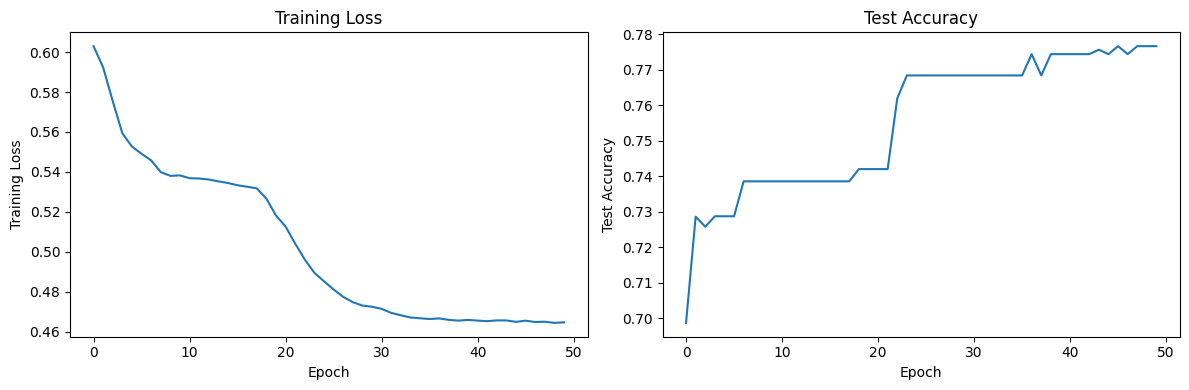

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss')

ax2.plot(test_accuracies)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Accuracy')

plt.tight_layout()
plt.show()

Output 7 [output7.png] loss curves for 2D embedding network

After changing from RNN to max pooling, increasing summary dim, and adding training epochs, the performance increased to an acceptable range. It turns that 2D embedding has a bottleneck around such accuracy.

### Plot Embedding for Problem 1

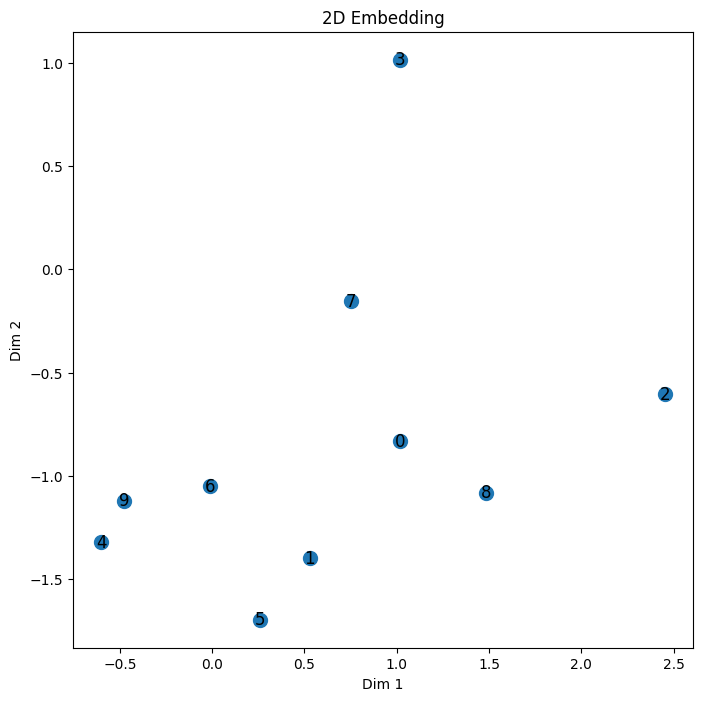

In [9]:
# Get the learned embedding
embedding_weights_1 = summary_net.embedding.weight.detach().numpy()

plt.figure(figsize=(8, 8))
plt.scatter(embedding_weights_1[:, 0], embedding_weights_1[:, 1], s=100)
for i in range(10):
    plt.annotate(str(i), (embedding_weights_1[i, 0], embedding_weights_1[i, 1]),
                ha='center', va='center')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.title('2D Embedding')
plt.show()

Output 8 [output8.png] 2D embedding

It seems like the learned embedding suggests the digits spread without much apparent structures. It's expected as digits don't need spatial relationships. The network, still, learned to separate the digits as possible, which is expected as they should be unique.

# fixed random embedding compared to trained embedding

In [10]:
summary_net_fixed = SummaryNetwork(embedding_dim=2, summary_dim=64)
summary_net_fixed.embedding.weight.requires_grad = False
query_net_fixed = QueryNetwork(summary_dim=64, embedding_dim=2, hidden_dim=64)

params_fixed = list(summary_net_fixed.fc.parameters()) + list(query_net_fixed.parameters())
optimizer_fixed = optim.Adam(params_fixed, lr=0.001)
criterion_fixed = nn.BCELoss()

num_epochs_bonus = 50
train_losses_fixed = []
test_accuracies_fixed = []

for epoch in range(num_epochs_bonus):
    summary_net_fixed.train()
    query_net_fixed.train()
    total_loss = 0

    for seqs, labels in train_loader:
        optimizer_fixed.zero_grad()
        summaries = summary_net_fixed(seqs)
        batch_size = seqs.size(0)
        loss = 0
        for q in range(10):
            query_vals = torch.full((batch_size,), q, dtype=torch.long)
            preds = query_net_fixed(summaries, query_vals)
            loss += criterion_fixed(preds, labels[:, q])
        loss = loss / 10
        loss.backward()
        optimizer_fixed.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses_fixed.append(avg_loss)

    summary_net_fixed.eval()
    query_net_fixed.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for seqs, labels in test_loader:
            summaries = summary_net_fixed(seqs)
            batch_size = seqs.size(0)
            # querying
            for q in range(10):
                query_vals = torch.full((batch_size,), q, dtype=torch.long)
                preds = query_net_fixed(summaries, query_vals)
                predicted = (preds > 0.5).float()
                correct += (predicted == labels[:, q]).sum().item()
                total += batch_size

    accuracy = correct / total
    test_accuracies_fixed.append(accuracy)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

Epoch 10, Loss: 0.5295, Test Accuracy: 0.7434
Epoch 20, Loss: 0.5091, Test Accuracy: 0.7552
Epoch 30, Loss: 0.4904, Test Accuracy: 0.7708
Epoch 40, Loss: 0.4828, Test Accuracy: 0.7665
Epoch 50, Loss: 0.4770, Test Accuracy: 0.7712


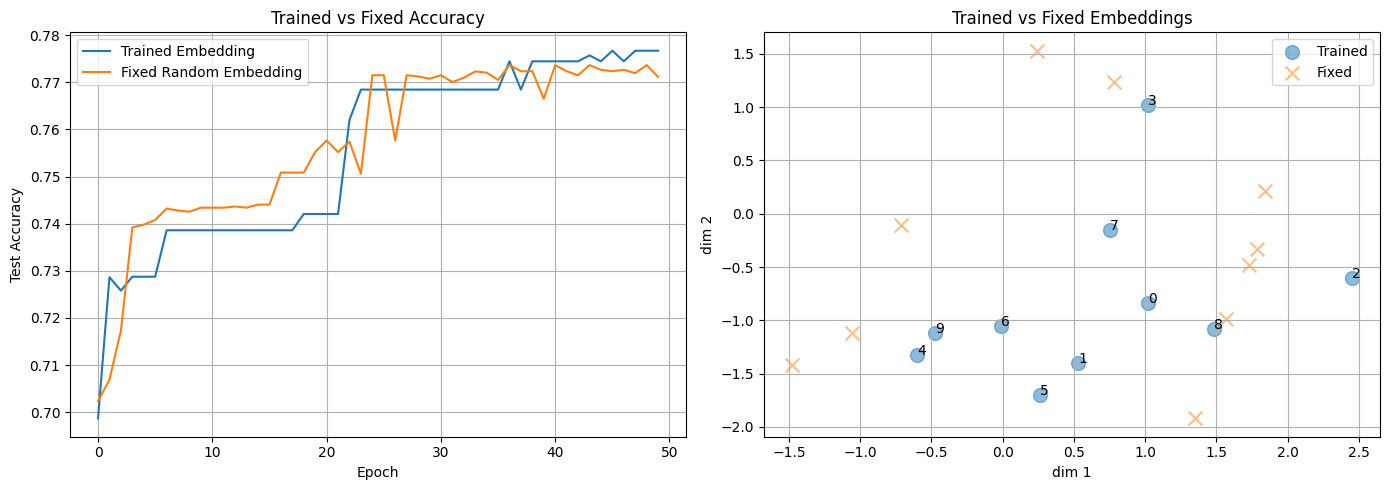

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(test_accuracies, label='Trained Embedding')
ax1.plot(test_accuracies_fixed, label='Fixed Random Embedding')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Trained vs Fixed Accuracy')
ax1.legend()
ax1.grid(True)

embedding_fixed = summary_net_fixed.embedding.weight.detach().numpy()
embedding_trained = summary_net.embedding.weight.detach().numpy()

ax2.scatter(embedding_trained[:, 0], embedding_trained[:, 1], s=100, alpha=0.5, label='Trained', marker='o')
ax2.scatter(embedding_fixed[:, 0], embedding_fixed[:, 1], s=100, alpha=0.5, label='Fixed', marker='x')

for i in range(10):
    ax2.annotate(str(i), (embedding_trained[i, 0], embedding_trained[i, 1]), fontsize=10)
ax2.set_xlabel('dim 1')
ax2.set_ylabel('dim 2')
ax2.set_title('Trained vs Fixed Embeddings')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


Output 9 [output9.png] trained v.s. trained embeddings

In [23]:
print(f"Trained embedding final accuracy: {test_accuracies[-1]:.4f}")
print(f"Fixed embedding final accuracy: {test_accuracies_fixed[-1]:.4f}")

Trained embedding final accuracy: 0.7767
Fixed embedding final accuracy: 0.7712


It seems like the result is meeting expectations, where trained embedding reached a slightly higher accuracy, and they both spread fairly unique, with trained are more clustered. Possibly because 2D has a bottleneck, the improvement is small.

# Sequential Training v.s. Simultaneous Training

In [26]:
summary_net_seq = SummaryNetwork(embedding_dim=2, summary_dim=64)
query_net_seq = QueryNetwork(summary_dim=64, embedding_dim=2, hidden_dim=64)

params_summary = list(summary_net_seq.parameters())
optimizer_summary = optim.Adam(params_summary, lr=0.001)
criterion_seq = nn.BCELoss()

# embedding and summary training
num_epochs_1 = 30

for epoch in range(num_epochs_1):
    summary_net_seq.train()
    query_net_seq.train()

    for seqs, labels in train_loader:
        optimizer_summary.zero_grad()
        summaries = summary_net_seq(seqs)
        batch_size = seqs.size(0)
        loss = 0
        # querying
        for q in range(10):
            query_vals = torch.full((batch_size,), q, dtype=torch.long)
            preds = query_net_seq(summaries, query_vals)
            loss += criterion_seq(preds, labels[:, q])
        loss = loss / 10
        loss.backward()
        optimizer_summary.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}")

for param in summary_net_seq.parameters():
    param.requires_grad = False


Epoch 10, Test Accuracy: 0.7835
Epoch 20, Test Accuracy: 0.7835
Epoch 30, Test Accuracy: 0.7835


In [25]:

# query with frozen summary
params_query = list(query_net_seq.parameters())
optimizer_query = optim.Adam(params_query, lr=0.001)
num_epochs_2 = 20
test_accuracies_seq = []

for epoch in range(num_epochs_2):
    query_net_seq.train()

    for seqs, labels in train_loader:
        optimizer_query.zero_grad()
        with torch.no_grad():
            summaries = summary_net_seq(seqs)
        batch_size = seqs.size(0)
        loss = 0
        for q in range(10):
            query_vals = torch.full((batch_size,), q, dtype=torch.long)
            preds = query_net_seq(summaries, query_vals)
            loss += criterion_seq(preds, labels[:, q])
        loss = loss / 10
        loss.backward()
        optimizer_query.step()

    query_net_seq.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for seqs, labels in test_loader:
            summaries = summary_net_seq(seqs)
            batch_size = seqs.size(0)
            for q in range(10):
                query_vals = torch.full((batch_size,), q, dtype=torch.long)
                preds = query_net_seq(summaries, query_vals)
                predicted = (preds > 0.5).float()
                correct += (predicted == labels[:, q]).sum().item()
                total += batch_size

    accuracy = correct / total
    test_accuracies_seq.append(accuracy)

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}")

  Epoch 5, Test Accuracy: 0.7513
  Epoch 10, Test Accuracy: 0.7823
  Epoch 15, Test Accuracy: 0.7843
  Epoch 20, Test Accuracy: 0.7835


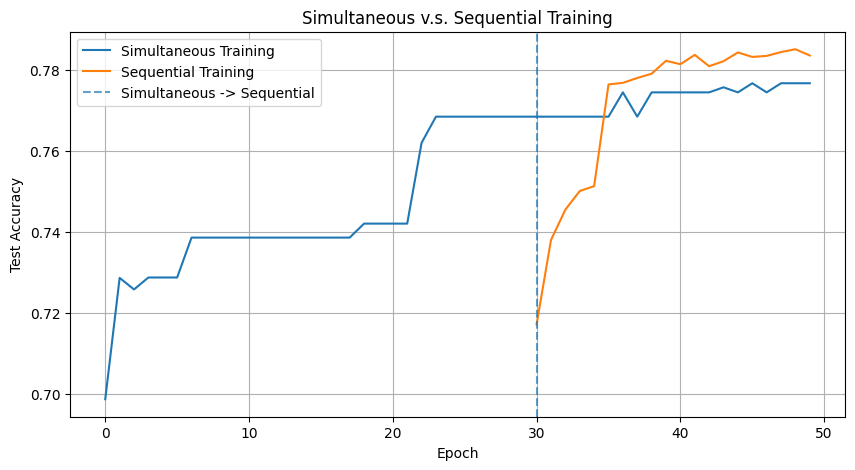

Final Accuracy - Simultaneous: 0.7767
Final Accuracy - Sequential: 0.7835


In [29]:
plt.figure(figsize=(10, 5))
plt.plot(test_accuracies, label='Simultaneous Training')
plt.plot(range(30, 50), test_accuracies_seq, label='Sequential Training')
plt.axvline(x=30, linestyle='--', alpha=0.7, label='Simultaneous -> Sequential')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Simultaneous v.s. Sequential Training')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Accuracy - Simultaneous: {test_accuracies[-1]:.4f}")
print(f"Final Accuracy - Sequential: {test_accuracies_seq[-1]:.4f}")

Output 10 [output10.png] Simultaneous v.s. Sequential Training

It seems like the simultaneous training slightly improved with sequential training, which is greater than what training embedding improved. From the trails so far, it would be getting slightly better performance to train in sequence.

# Test query network: if q and q+1 occurred next to each other.

In [15]:
class ConsecutiveDataset(Dataset):
    def __init__(self, num_samples=10000, seq_length_range=(5, 20)):
        self.num_samples = num_samples
        self.seq_length_range = seq_length_range
        self.data = self._generate_data()

    def _generate_data(self):
        data = []
        for _ in range(self.num_samples):
            length = np.random.randint(self.seq_length_range[0], self.seq_length_range[1] + 1)
            seq = np.random.randint(0, 10, size=length)
            # For each query value 0-8, check if q and q+1 appear consecutively
            labels = np.zeros(9, dtype=np.float32)
            for i in range(len(seq) - 1):
                if seq[i+1] == seq[i] + 1:  # Found consecutive pair
                    labels[seq[i]] = 1
            data.append((seq, labels))
        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq, labels = self.data[idx]
        return torch.LongTensor(seq), torch.FloatTensor(labels)

# Create datasets for consecutive problem
train_dataset_2 = ConsecutiveDataset(num_samples=10000)
test_dataset_2 = ConsecutiveDataset(num_samples=2000)

train_loader_2 = DataLoader(train_dataset_2, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader_2 = DataLoader(test_dataset_2, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Training samples: {len(train_dataset_2)}")
seq, labels = train_dataset_2[0]
print(f"Sample sequence: {seq}")
print(f"Labels (which consecutive pairs appeared): {labels}")

Training samples: 10000
Sample sequence: tensor([7, 5, 4, 4, 2, 0, 0, 4, 0, 1])
Labels (which consecutive pairs appeared): tensor([1., 0., 0., 0., 0., 0., 0., 0., 0.])


In [16]:
class QueryNetworkConsecutive(nn.Module):
    def __init__(self, summary_dim=16, embedding_dim=2, hidden_dim=32):
        super().__init__()
        self.query_embedding = nn.Embedding(9, embedding_dim)  # Only 0-8 for consecutive queries
        self.fc1 = nn.Linear(summary_dim + embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, summary, query_val):
        query_emb = self.query_embedding(query_val)
        combined = torch.cat([summary, query_emb], dim=1)
        hidden = torch.relu(self.fc1(combined))
        logit = self.fc2(hidden).squeeze(1)
        return torch.sigmoid(logit)

In [33]:
# Initialize networks for problem 2
summary_net_2 = SummaryNetwork(embedding_dim=2, summary_dim=16)
query_net_2 = QueryNetworkConsecutive(summary_dim=16, embedding_dim=2, hidden_dim=32)

params_2 = list(summary_net_2.parameters()) + list(query_net_2.parameters())
optimizer_2 = optim.Adam(params_2, lr=0.001)
criterion_2 = nn.BCELoss()

# Training loop for consecutive problem
num_epochs = 20
train_losses_2 = []
test_accuracies_2 = []

for epoch in range(num_epochs):
    summary_net_2.train()
    query_net_2.train()
    total_loss = 0

    for seqs, labels in train_loader_2:
        optimizer_2.zero_grad()

        summaries = summary_net_2(seqs)
        batch_size = seqs.size(0)
        loss = 0

        # Query for digits 0-8
        for q in range(9):
            query_vals = torch.full((batch_size,), q, dtype=torch.long)
            preds = query_net_2(summaries, query_vals)
            loss += criterion_2(preds, labels[:, q])

        loss = loss / 9
        loss.backward()
        optimizer_2.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_2)
    train_losses_2.append(avg_loss)

    # Evaluation
    summary_net_2.eval()
    query_net_2.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for seqs, labels in test_loader_2:
            summaries = summary_net_2(seqs)
            batch_size = seqs.size(0)

            for q in range(9):
                query_vals = torch.full((batch_size,), q, dtype=torch.long)
                preds = query_net_2(summaries, query_vals)
                predicted = (preds > 0.5).float()
                correct += (predicted == labels[:, q]).sum().item()
                total += batch_size

    accuracy = correct / total
    test_accuracies_2.append(accuracy)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

Epoch 1, Loss: 0.4261, Test Accuracy: 0.8874
Epoch 2, Loss: 0.3454, Test Accuracy: 0.8874
Epoch 3, Loss: 0.3430, Test Accuracy: 0.8874
Epoch 4, Loss: 0.3417, Test Accuracy: 0.8874
Epoch 5, Loss: 0.3410, Test Accuracy: 0.8874
Epoch 6, Loss: 0.3402, Test Accuracy: 0.8874
Epoch 7, Loss: 0.3397, Test Accuracy: 0.8874
Epoch 8, Loss: 0.3396, Test Accuracy: 0.8874
Epoch 9, Loss: 0.3374, Test Accuracy: 0.8874
Epoch 10, Loss: 0.3363, Test Accuracy: 0.8874
Epoch 11, Loss: 0.3351, Test Accuracy: 0.8874
Epoch 12, Loss: 0.3343, Test Accuracy: 0.8874
Epoch 13, Loss: 0.3333, Test Accuracy: 0.8874
Epoch 14, Loss: 0.3322, Test Accuracy: 0.8874
Epoch 15, Loss: 0.3310, Test Accuracy: 0.8874
Epoch 16, Loss: 0.3306, Test Accuracy: 0.8874
Epoch 17, Loss: 0.3306, Test Accuracy: 0.8874
Epoch 18, Loss: 0.3300, Test Accuracy: 0.8874
Epoch 19, Loss: 0.3299, Test Accuracy: 0.8874
Epoch 20, Loss: 0.3295, Test Accuracy: 0.8874


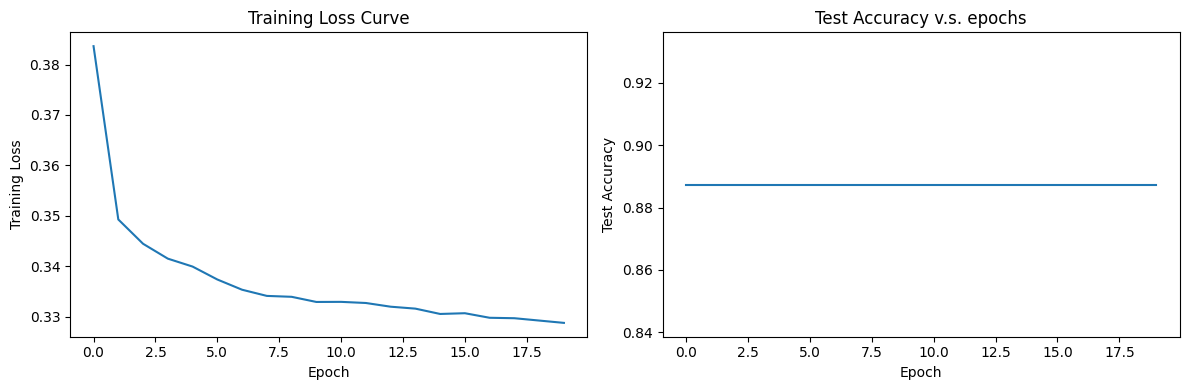

In [31]:
# Visualize training for problem 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses_2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Curve')

ax2.plot(test_accuracies_2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Accuracy v.s. epochs')

plt.tight_layout()
plt.show()

Output 11 [output11.png] Training loss curve and testing accuracy

The curves seem to meet expectations, where the consecutive test reached a much better accuracy. Possibly because the task is easier with sparser labels, where the model learned quickly and reached plateau quickly.

### Compare Embeddings Between Two Problems

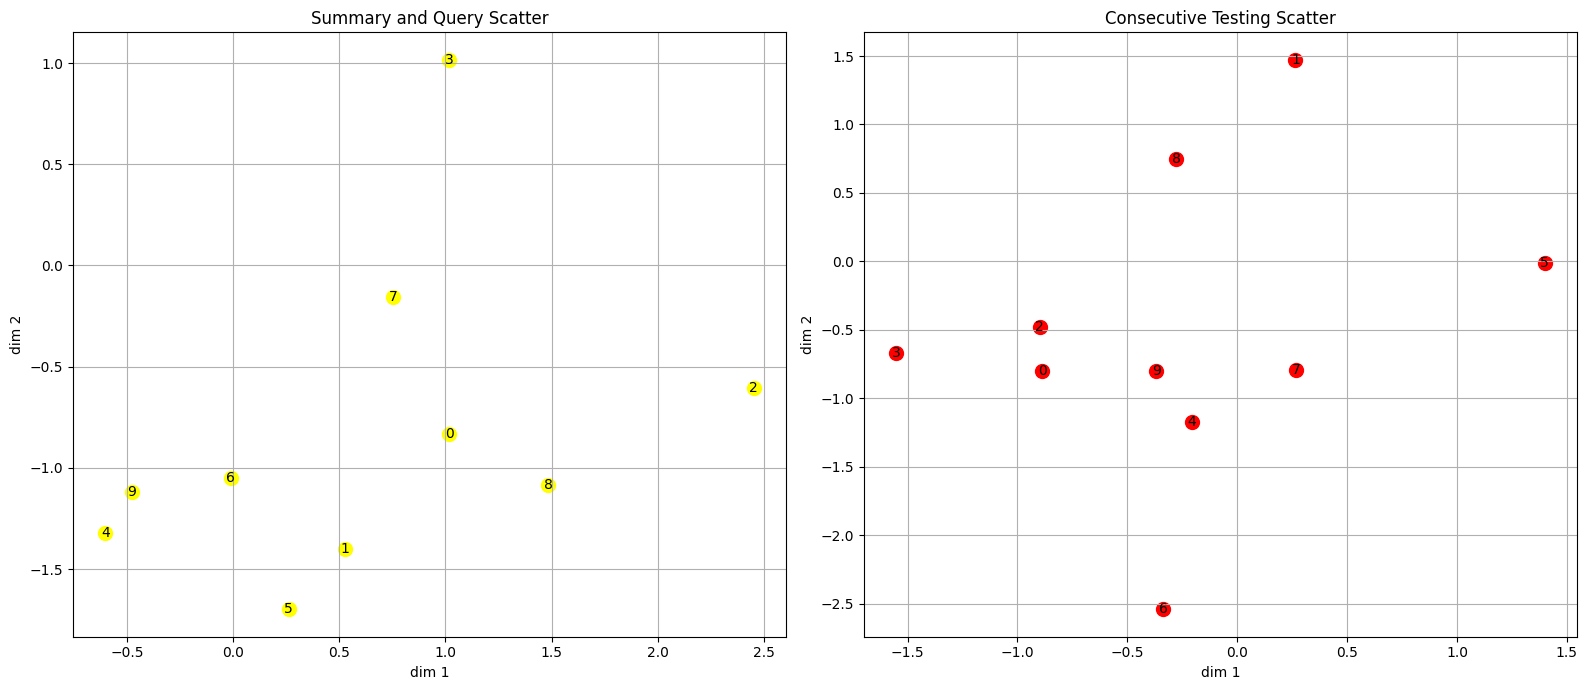

In [36]:
embedding_weights_2 = summary_net_2.embedding.weight.detach().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.scatter(embedding_weights_1[:, 0], embedding_weights_1[:, 1], s=100, c='yellow')
for i in range(10):
    ax1.annotate(str(i), (embedding_weights_1[i, 0], embedding_weights_1[i, 1]),
                ha='center', va='center')
ax1.set_xlabel('dim 1')
ax1.set_ylabel('dim 2')
ax1.set_title('Summary and Query Scatter')
ax1.grid(True)

ax2.scatter(embedding_weights_2[:, 0], embedding_weights_2[:, 1], s=100, c='red')
for i in range(10):
    ax2.annotate(str(i), (embedding_weights_2[i, 0], embedding_weights_2[i, 1]),
                ha='center', va='center')
ax2.set_xlabel('dim 1')
ax2.set_ylabel('dim 2')
ax2.set_title('Consecutive Testing Scatter')
ax2.grid(True)

plt.tight_layout()
plt.show()

Output 12 [output12.png] Scatter plot for two problems

Both plots are scattered. While problem 1 is completely random, problem 2 shows a tighter distribution. The test accuracy suggests it might developed alternative methods to identify consecutive patterns. Possibly because of 2D limitations, it would be difficult to arrange 10 digits into pairs that are consistently close.